<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **SpaceX  Falcon 9 First Stage Landing Prediction**


 ## Hands-on Lab: Complete the EDA with Visualization


Estimated time needed: **70** minutes


In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage. 

In this lab, you will perform Exploratory Data Analysis and Feature Engineering.


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planned. Space X performs a controlled landing in the oceans. 


  ## Objectives
Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

- Exploratory Data Analysis
- Preparing Data  Feature Engineering 


----


Install the below libraries


### Import Libraries and Define Auxiliary Functions


We will import the following libraries the lab 



In [2]:
# andas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

## Exploratory Data Analysis 


First, let's read the SpaceX dataset into a Pandas dataframe and print its summary


In [3]:
df=pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# If you were unable to complete the previous lab correctly you can uncomment and load this csv

# df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/dataset_part_2.csv')

df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [4]:
# Inspección de columnas para verificar nomenclatura profesional
print("Columnas disponibles:", df.columns.tolist())
print(df.head(1))

Columnas disponibles: ['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'Class']
   FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite  \
0             1  2010-06-04       Falcon 9  6104.959412   LEO  CCAFS SLC 40   

     Outcome  Flights  GridFins  Reused   Legs LandingPad  Block  ReusedCount  \
0  None None        1     False   False  False        NaN    1.0            0   

  Serial  Longitude   Latitude  Class  
0  B0003 -80.577366  28.561857      0  


First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass is also important; it seems the more massive the payload, the less likely the first stage will return.


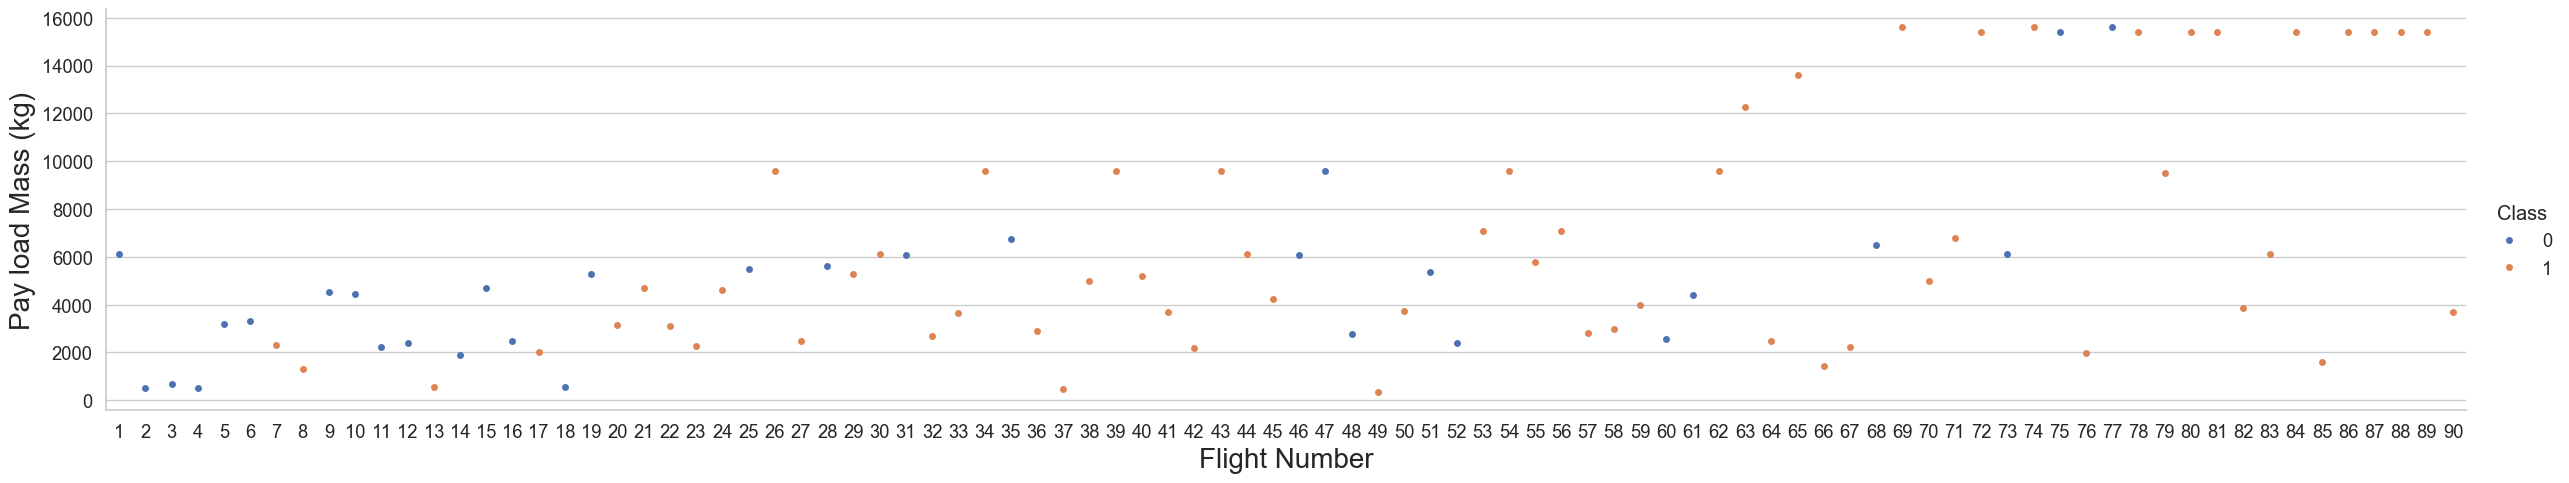

In [5]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

Next, let's drill down to each site visualize its detailed launch records.


### TASK 1: Visualize the relationship between Flight Number and Launch Site


Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>


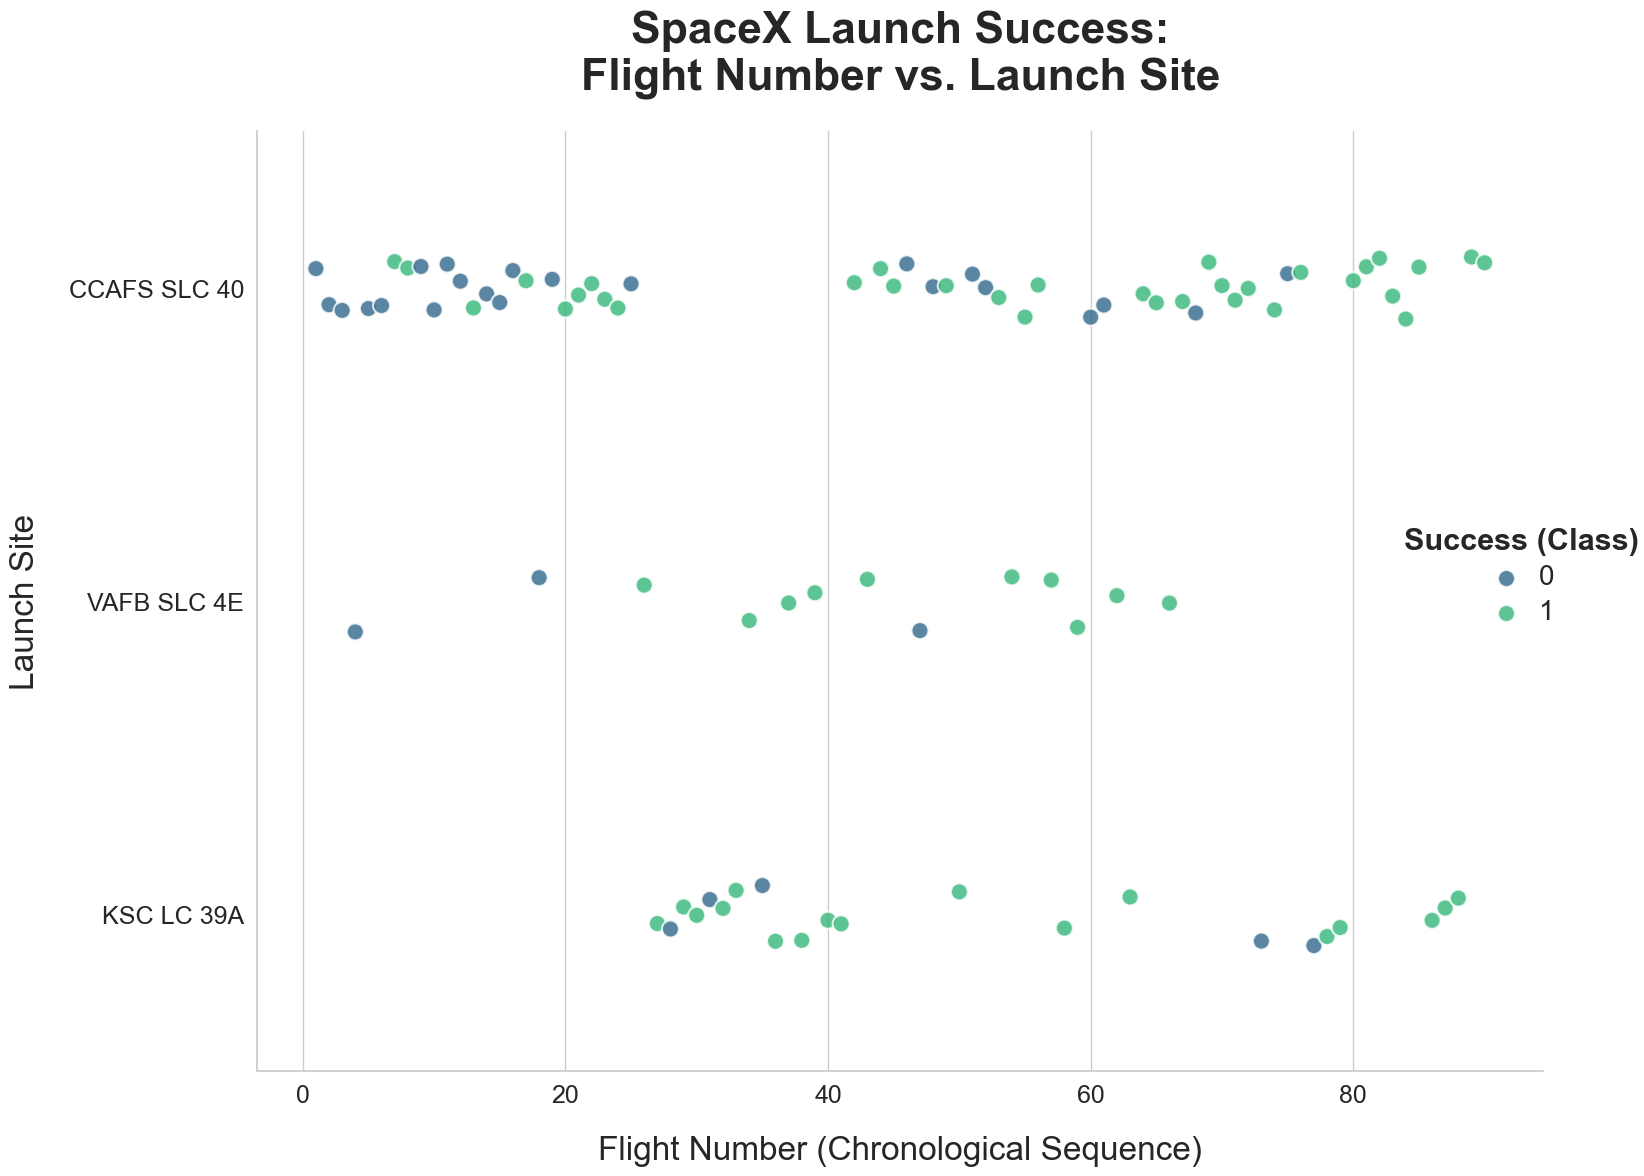

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN DE ESCALA PROFESIONAL ---
# Definimos el tamaño del lienzo para un formato casi cuadrado (Aprox 4:3)
# Aumentamos 'height' y reducimos 'aspect' drásticamente.
alto_pulgadas = 12
ancho_pulgadas = alto_pulgadas * 1.25  # Un poco más ancho que alto

# 1. Configuración del estilo global (Escala de fuente base aumentada)
# sns.set_theme(style="whitegrid", font_scale=1.5) # Comentado, lo haremos manual para control total

# 2. Generación del Catplot (Formato Grande y Cuadrado)
cat_plot = sns.catplot(
    data=df,
    x="FlightNumber",
    y="LaunchSite",
    hue="Class",
    aspect=1.25,      # CLAVE: Un aspect bajo (cercano a 1) hace la figura cuadrada.
    height=alto_pulgadas, # Aumentado dramáticamente para ganar verticalidad y tamaño real.
    s=150,            # CLAVE: Tamaño de punto (s) MASIVO para visibilidad en formato grande.
    palette="viridis",
    alpha=0.8,
    edgecolor="w",
    linewidth=1.5,
    kind="strip",     # Aseguramos el tipo de gráfico
)

# 3. Refinamiento de etiquetas y títulos con Jerarquía Visual (Fuentes Enormes)
plt.title(
    "SpaceX Launch Success:\nFlight Number vs. Launch Site", 
    fontsize=32,      # Título Enorme
    pad=30,           # Mucho margen para respirar
    fontweight='bold',
    loc='center'
)

# Etiquetas de ejes con fuentes grandes
plt.xlabel("Flight Number (Chronological Sequence)", fontsize=24, labelpad=20)
plt.ylabel("Launch Site", fontsize=24, labelpad=20)

# Ajuste de las fuentes de los Ticks (los números de los ejes)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# 4. Ajuste manual de la leyenda (Escala Enorme)
cat_plot._legend.set_title("Success (Class)")
plt.setp(cat_plot._legend.get_texts(), fontsize='20') 
plt.setp(cat_plot._legend.get_title(), fontsize='22', fontweight='bold')

# Opcional: Ajuste fino de la posición de la leyenda para que no se corte
cat_plot._legend.set_bbox_to_anchor((1.05, 0.5))

# 5. Optimización final del layout
plt.tight_layout()

plt.show()

Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.


### TASK 2: Visualize the relationship between Payload and Launch Site


We also want to observe if there is any relationship between launch sites and their payload mass.


/tmp/ipykernel_19561/1730633665.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


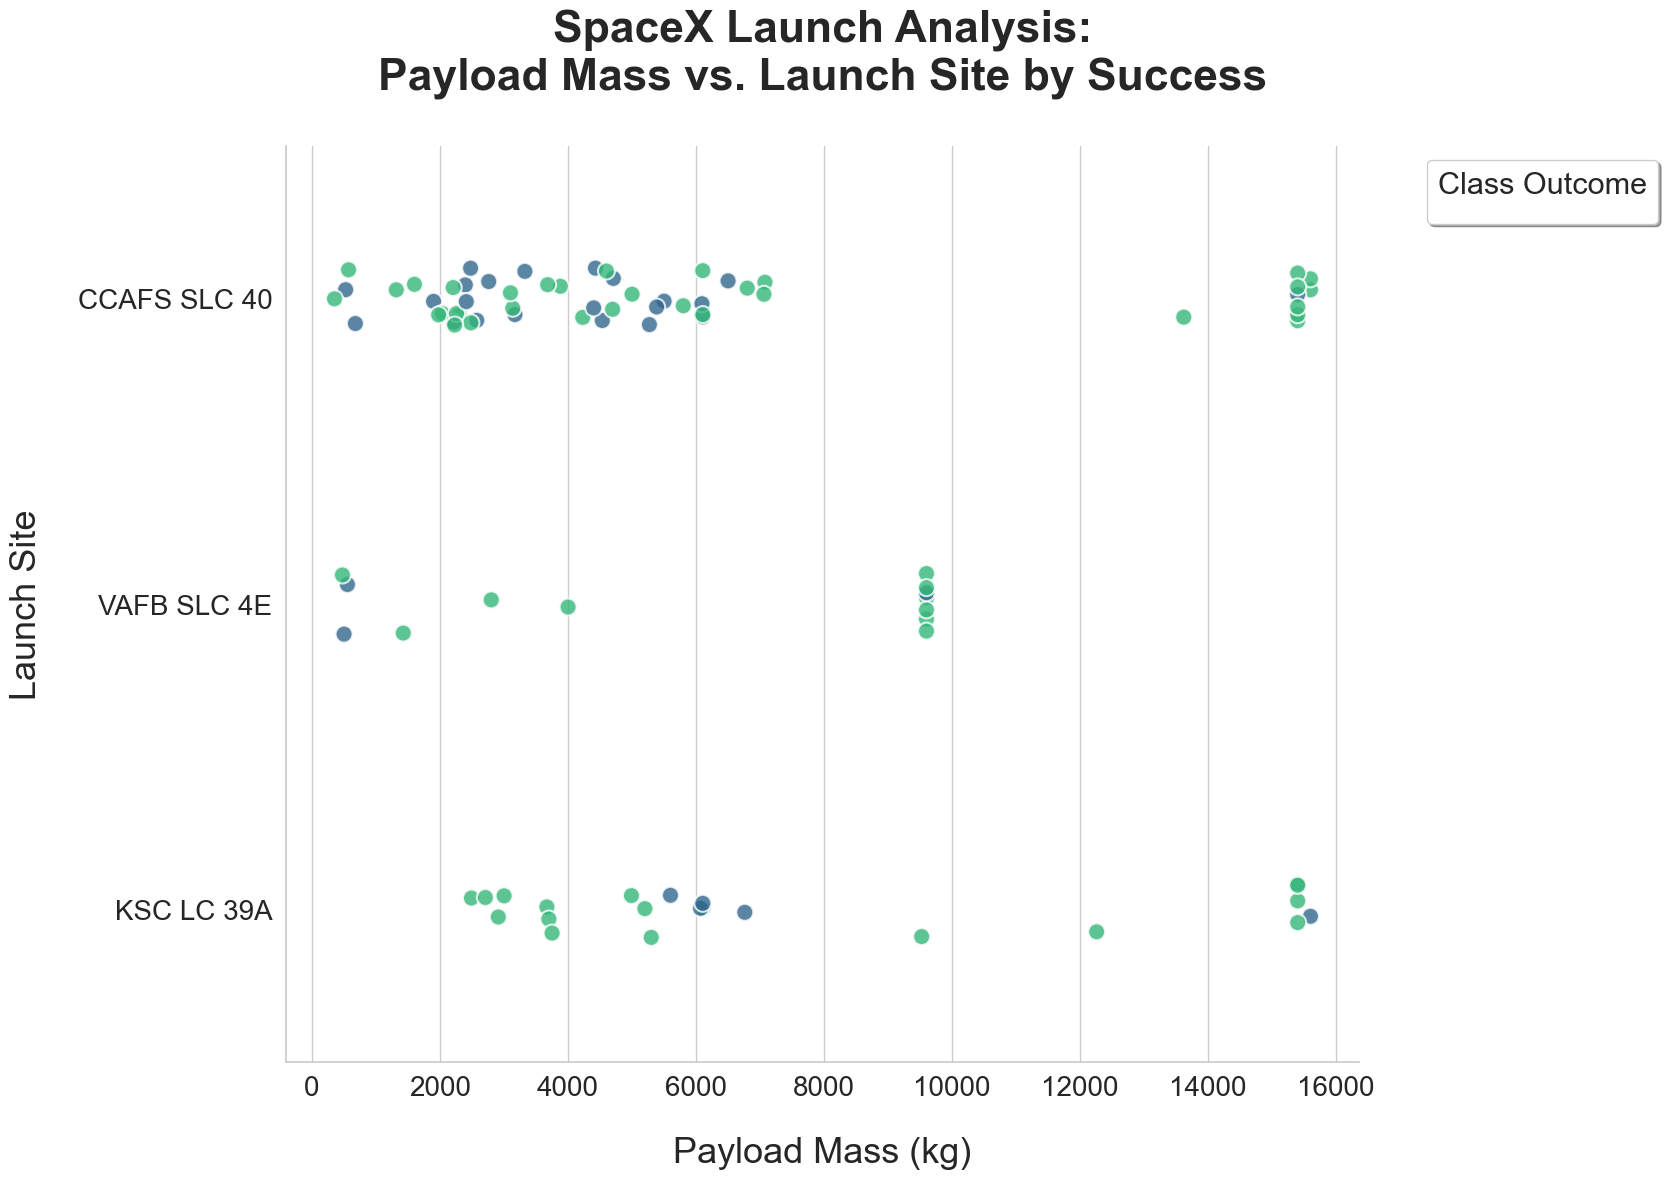

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. CONFIGURACIÓN DE ESTILO PROFESIONAL (PRESENTATION) ---
# Usamos 'talk' para fuentes grandes por defecto y 'whitegrid' para rigor.
sns.set_context("talk") 
sns.set_theme(style="whitegrid")

# --- 2. GENERACIÓN DEL GRÁFICO (FORMATO CUADRADO Y GRANDE) ---
# CLAVE: Para que sea cuadrado (o casi), el aspect debe ser bajo (cercano a 1).
# Si subimos height a 10 y bajamos aspect a 1.25, el ancho será 12.5 (proporción ~4:3).
fig_height = 10
fig_aspect = 1.25 # Horizontal/Vertical

cat_plot = sns.catplot(
    data=df, 
    x="PayloadMass", 
    y="LaunchSite", 
    hue="Class", 
    aspect=fig_aspect, # CLAVE: Aspecto casi cuadrado
    height=fig_height, # CLAVE: Altura física grande
    s=150,            # CLAVE: Puntos masivos para visibilidad en formato grande
    alpha=0.8,        
    palette="viridis",
    legend=False,     # La gestionaremos manualmente
    edgecolor="w",    # Borde blanco para resaltar puntos
    linewidth=1.5
)

# --- 3. REFINAMIENTO DE ETIQUETAS (INGLÉS, PEP8 STANDARDS) ---
# Fuentes grandes manuales para control total, con márgenes (pad).
plt.xlabel("Payload Mass (kg)", fontsize=26, labelpad=25)
plt.ylabel("Launch Site", fontsize=26, labelpad=25)
plt.title(
    "SpaceX Launch Analysis:\nPayload Mass vs. Launch Site by Success", 
    fontsize=32, 
    pad=40, 
    fontweight='bold',
    loc='center'
)

# Ajuste manual de los ticks de los ejes (Fuentes grandes)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# --- 4. GESTIÓN DE LEYENDA (GRANDE Y FUERA) ---
# Posicionamos la leyenda a la derecha, fuera del área de datos.
plt.legend(
    title="Class Outcome", 
    title_fontsize='22', 
    fontsize='20', 
    bbox_to_anchor=(1.05, 1), # Fuera, arriba a la derecha
    loc='upper left',
    frameon=True,
    shadow=True
)

# Opcional: Salvar en alta resolución para la slide
# plt.savefig("eda_payload_vs_site_square.png", dpi=300, bbox_inches='tight')

plt.show()

Now if you observe Payload Vs. Launch Site scatter point chart you will find for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).


### TASK  3: Visualize the relationship between success rate of each orbit type


Next, we want to visually check if there are any relationship between success rate and orbit type.


Let's create a `bar chart` for the sucess rate of each orbit


/tmp/ipykernel_19561/935669434.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


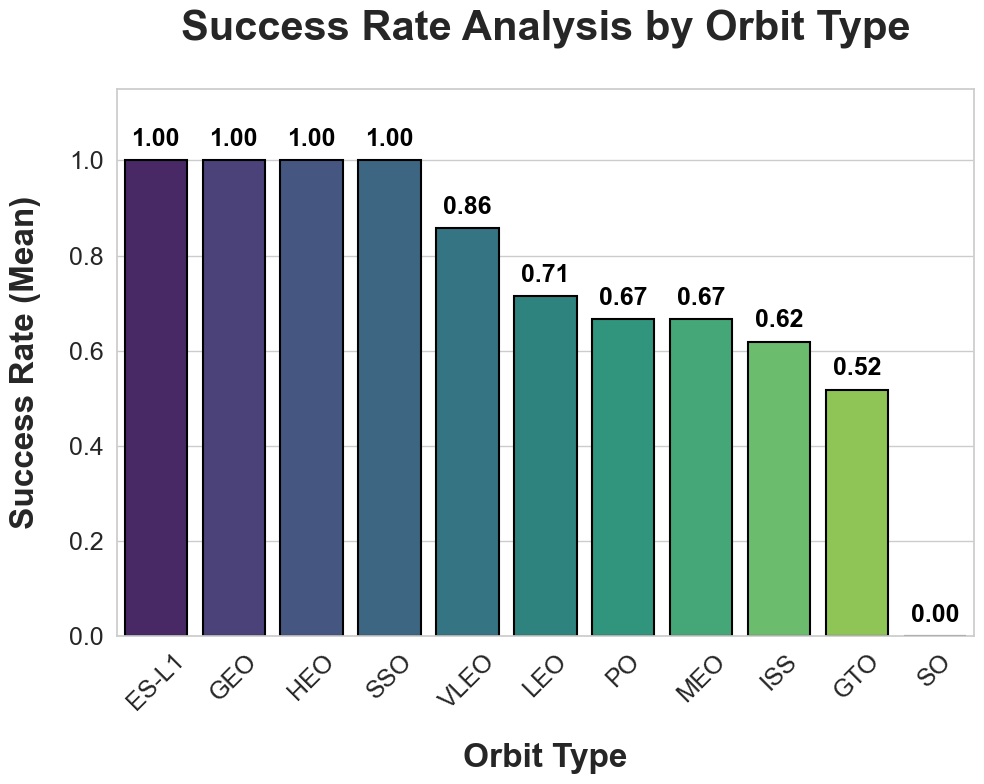

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Data Processing: Grouping and Sorting for professional analysis
orbit_success = df.groupby("Orbit")["Class"].mean().sort_values(ascending=False).reset_index()

# 2. Professional Aesthetics Configuration (Presentation Context)
sns.set_context("talk")
sns.set_theme(style="whitegrid")

# 3. Bar Chart Generation (Large, Square-ish Format)
# Using a 12x10 size for that high-visibility "square" impact on the slide
plt.figure(figsize=(10, 8))
barplot = sns.barplot(
    data=orbit_success,
    x="Orbit",
    y="Class",
    palette="viridis",
    edgecolor="black",
    linewidth=1.5
)

# 4. Professional Labeling and Metadata (English)
plt.xlabel("Orbit Type", fontsize=24, fontweight='bold', labelpad=20)
plt.ylabel("Success Rate (Mean)", fontsize=24, fontweight='bold', labelpad=20)
plt.title("Success Rate Analysis by Orbit Type", fontsize=30, pad=35, fontweight='bold')

# 5. Data Annotation: Adding precision values on top of bars
for p in barplot.patches:
    barplot.annotate(
        format(p.get_height(), '.2f'), 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        xytext=(0, 15), 
        textcoords='offset points',
        fontsize=18, 
        fontweight='bold',
        color='black'
    )

# 6. Final Adjustments
plt.xticks(fontsize=18, rotation=45) # Rotation for better label readability
plt.yticks(fontsize=18)
plt.ylim(0, 1.15) # Extra space for the annotations
plt.tight_layout()

plt.show()

Analyze the ploted bar chart try to find which orbits have high sucess rate.


### TASK  4: Visualize the relationship between FlightNumber and Orbit type


For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.


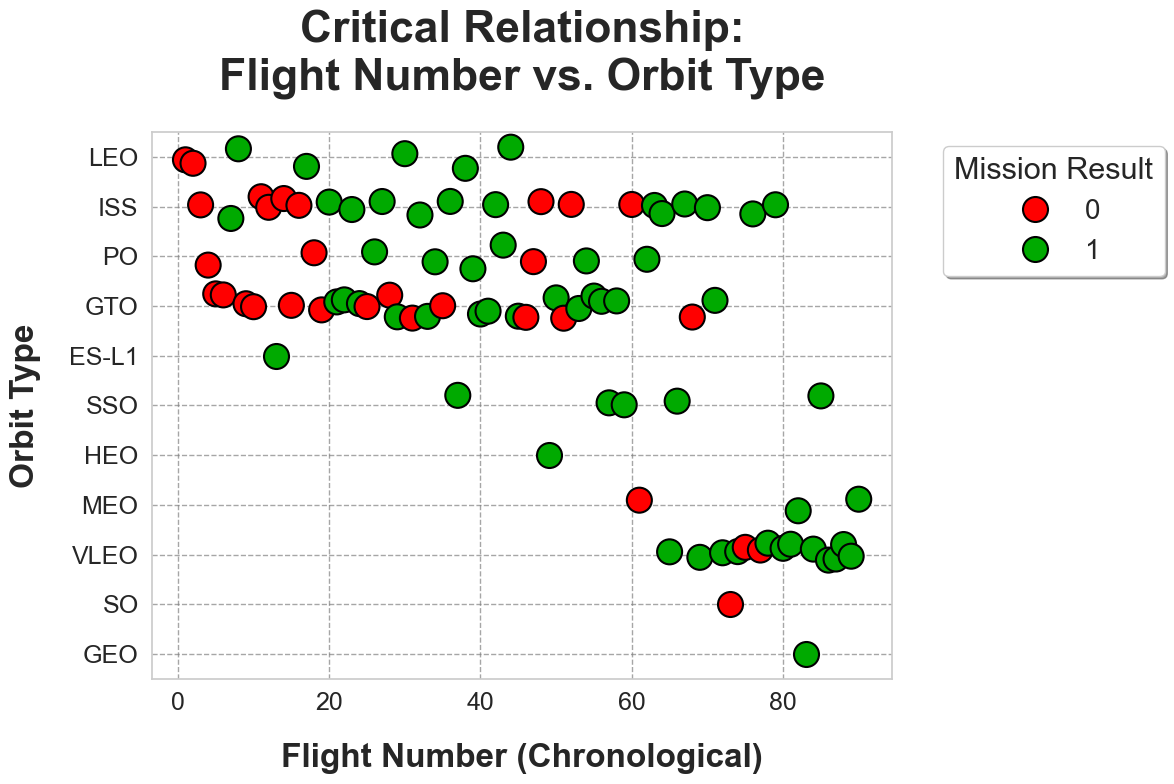

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Professional Aesthetics Configuration (Presentation Context)
# Usamos un formato casi cuadrado (14x12) para que destaque en la slide
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# 2. Scatter Plot (Stripplot) with High Contrast & Solid Markers
# Custom palette: Red for Failure (0), Solid Green for Success (1)
stripplot = sns.stripplot(
    data=df, 
    x="FlightNumber", 
    y="Orbit", 
    hue="Class", 
    palette={0: "#FF0000", 1: "#00AA00"}, 
    size=18,           # Large markers for visibility
    jitter=0.25,       # Slight dispersion to prevent overlap
    alpha=1.0,         # Full opacity for solid impact
    linewidth=1.5,     # Black outline for maximum contrast
    edgecolor="black"
)

# 3. High-Visibility Labeling (English - Professional Standards)
plt.title("Critical Relationship:\nFlight Number vs. Orbit Type", 
          fontsize=32, fontweight='bold', pad=30)
plt.xlabel("Flight Number (Chronological)", fontsize=24, fontweight='bold', labelpad=20)
plt.ylabel("Orbit Type", fontsize=24, fontweight='bold', labelpad=20)

# 4. Enhanced Grid for Data Alignment
plt.grid(True, linestyle='--', alpha=0.7, color='gray')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# 5. Professional Legend Management
plt.legend(
    title="Mission Result", 
    title_fontsize='22', 
    fontsize='20', 
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    frameon=True, 
    shadow=True
)

plt.tight_layout()
plt.show()

You should see that in the LEO orbit the Success appears related to the number of flights; on the other hand, there seems to be no relationship between flight number when in GTO orbit.


### TASK  5: Visualize the relationship between Payload and Orbit type


Similarly, we can plot the Payload vs. Orbit scatter point charts to reveal the relationship between Payload and Orbit type


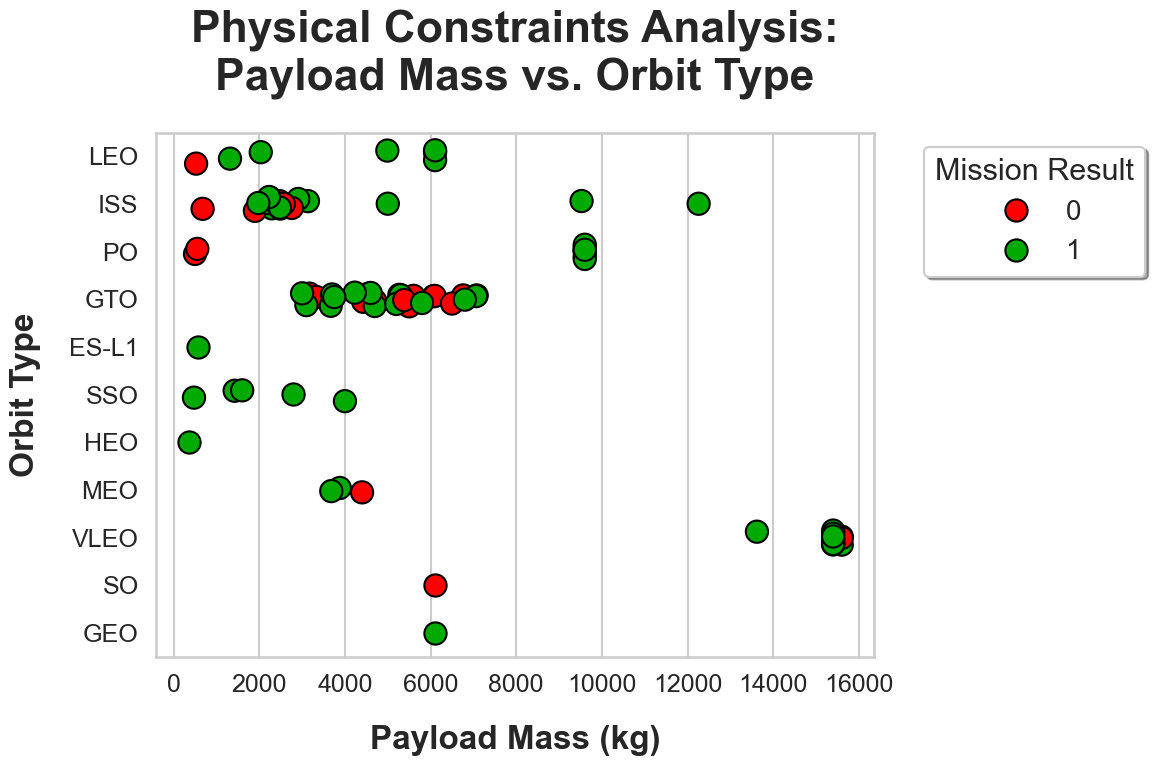

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Professional Aesthetics Configuration (Presentation Context)
# We use a 14x12 ratio for a high-impact, square-ish visualization
plt.figure(figsize=(14, 12))
sns.set_theme(style="whitegrid")
sns.set_context("talk")

# 2. Scatter Plot Generation (Stripplot for high density control)
# x = PayloadMass (Physical independent variable)
# y = Orbit (Categorical destination)
# hue = Class (Outcome: 0=Fail, 1=Success)
stripplot = sns.stripplot(
    data=df, 
    x="PayloadMass", 
    y="Orbit", 
    hue="Class", 
    palette={0: "#FF0000", 1: "#00AA00"}, # Pure Red and Solid Green
    size=16,            # Large markers for clarity
    jitter=0.15,        # Slight dispersion to handle overlapping points
    alpha=1.0,          # Full opacity for maximum visual impact
    linewidth=1.5,      # Defined borders
    edgecolor="black"   # Black outline to stand out against the grid
)

# 3. Metadata Refinement (Professional English Standards)
plt.title("Physical Constraints Analysis:\nPayload Mass vs. Orbit Type", 
          fontsize=32, fontweight='bold', pad=30)
plt.xlabel("Payload Mass (kg)", fontsize=24, fontweight='bold', labelpad=20)
plt.ylabel("Orbit Type", fontsize=24, fontweight='bold', labelpad=20)

# 4. Technical Legend Adjustment
plt.legend(
    title="Mission Result", 
    title_fontsize='22', 
    fontsize='20', 
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    frameon=True, 
    shadow=True
)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()

With heavy payloads the successful landing or positive landing rate are more for Polar,LEO and ISS.   

However for GTO we cannot distinguish this well as both positive landing rate and negative landing(unsuccessful mission) are both there here.




### TASK  6: Visualize the launch success yearly trend


You can plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend. 


The function will help you get the year from the date:


In [21]:
# A function to Extract years from the date 
year=[]
def Extract_year(date):
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
    

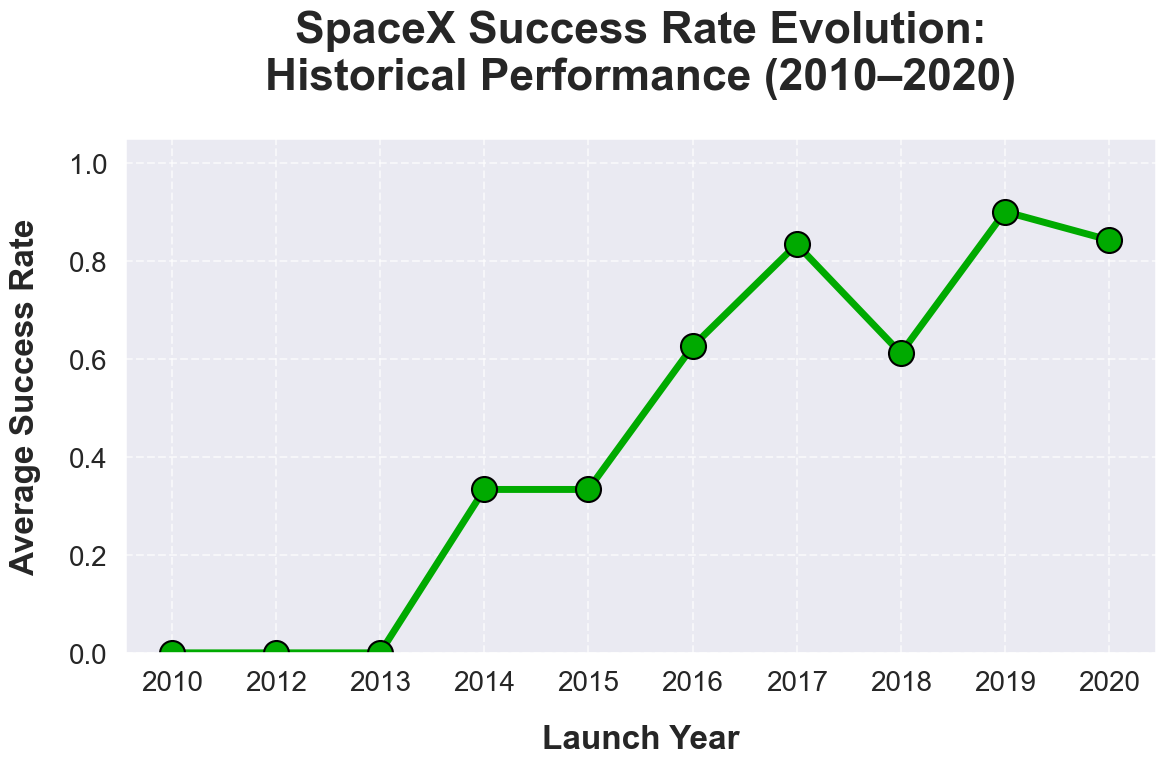

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Year Extraction and Data Grouping
# (Assuming Extract_year function is already defined in your notebook)
#df["Year"] = Extract_year(df["Date"])
df_yearly_success = df.groupby("Year")["Class"].mean().reset_index()

# 2. Professional Aesthetics Configuration (Presentation Context)
# We use a 14x12 ratio for a high-impact, square-ish visualization
plt.figure(figsize=(12, 8))
sns.set_theme(style="darkgrid")
sns.set_context("talk")

# 3. Line Chart Generation (Solid Architecture)
# Thick lines and large markers to avoid "weak" visual presence on slides
sns.lineplot(
    data=df_yearly_success, 
    x="Year", 
    y="Class", 
    marker="o", 
    markersize=18,      # Large, solid markers
    linewidth=5,        # Very thick line for visual authority
    color="#00AA00",    # Solid Green representing accumulated success
    markeredgecolor="black",
    markeredgewidth=1.5
)

# 4. Metadata Refinement (Professional English Standards)
plt.title("SpaceX Success Rate Evolution:\nHistorical Performance (2010–2020)", 
          fontsize=32, fontweight='bold', pad=35)
plt.xlabel("Launch Year", fontsize=24, fontweight='bold', labelpad=20)
plt.ylabel("Average Success Rate", fontsize=24, fontweight='bold', labelpad=20)

# 5. Axis and Grid Precision
plt.ylim(0, 1.05) # Ensures Y-axis covers 0% to 100% clearly
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True, which='both', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

You can observe that the success rate since 2013 kept increasing till 2017 (stable in 2014) and after 2015 it started increasing.


## Features Engineering 


By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.


In [28]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


 ### TASK  7: Create dummy variables to categorical columns


Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.


In [29]:

# 1. Definición de las columnas categóricas para transformación
categorical_columns = ['Orbit', 'LaunchSite', 'LandingPad', 'Serial']

# 2. Aplicación de get_dummies
# El parámetro 'columns' permite aplicar la transformación solo a las deseadas
# manteniendo el resto del dataframe intacto (como PayloadMass o FlightNumber)
features_one_hot = pd.get_dummies(
    features, 
    columns=categorical_columns,
    prefix=categorical_columns # Mantiene una nomenclatura profesional y clara
)

# 3. Visualización de los resultados (Primeras 5 filas)
# Nota: Verás que el número de columnas (shape[1]) aumentará significativamente
print(f"Dimensiones originales: {features.shape}")
print(f"Nuevas dimensiones tras One-Hot Encoding: {features_one_hot.shape}")
print("\n--- Vista previa de features_one_hot ---")
features_one_hot.head()

Dimensiones originales: (90, 12)
Nuevas dimensiones tras One-Hot Encoding: (90, 80)

--- Vista previa de features_one_hot ---


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### TASK  8: Cast all numeric columns to `float64`


Now that our <code>features_one_hot</code> dataframe only contains numbers cast the entire dataframe to variable type <code>float64</code>


In [30]:
# HINT: use astype function
# Cast the entire dataframe to float64 as requested
# Using .astype('float64') ensures all numerical features are in the 
# high-precision format required for physical modeling and ML stability.
features_one_hot = features_one_hot.astype('float64')

# Display the result and verify the dtypes
print("--- Tipos de datos actualizados (Dtypes) ---")
print(features_one_hot.dtypes.unique()) # Debería mostrar solo [dtype('float64')]

print("\n--- Vista previa de features_one_hot (Float64) ---")
features_one_hot.head()

--- Tipos de datos actualizados (Dtypes) ---
[dtype('float64')]

--- Vista previa de features_one_hot (Float64) ---


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range. 


<code>features_one_hot.to_csv('dataset_part_3.csv', index=False)</code>


In [31]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)

## Authors


<a href="https://www.linkedin.com/in/joseph-s-50398b136/">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


<a href="https://www.linkedin.com/in/nayefaboutayoun/">Nayef Abou Tayoun</a> is a Data Scientist at IBM and pursuing a Master of Management in Artificial intelligence degree at Queen's University.


## Change Log


| Date (YYYY-MM-DD) | Version | Changed By | Change Description      |
| ----------------- | ------- | ---------- | ----------------------- |
| 2021-10-12        | 1.1     | Lakshmi Holla     | Modified markdown |
| 2020-09-20        | 1.0     | Joseph     | Modified Multiple Areas |
| 2020-11-10       | 1.1    | Nayef      | updating the input data |


Copyright © 2020 IBM Corporation. All rights reserved.
